#*Load Libraries*

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras as keras
import tensorflow.keras.layers as layers
import pandas as pd
import matplotlib.pyplot as plt

#*Simulate two features and ground truth labels.*

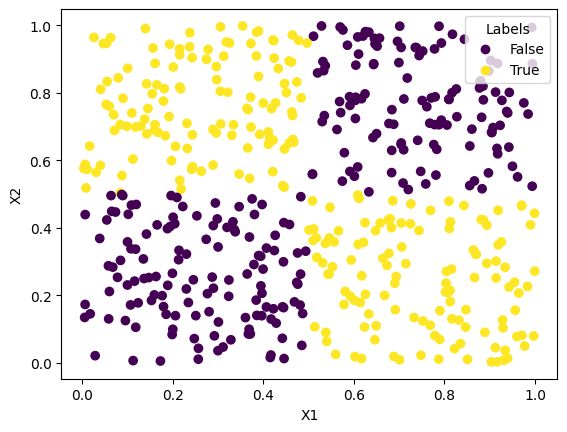

In [24]:
X = np.random.rand(500,2)
y = np.zeros((500,1))
y = ((X[:,0]<0.5)*(X[:,1]>=0.5)*1) + ((X[:,0]>=0.5)*(X[:,1]<0.5)*1)

# Leave this alone; we will come back to it later.
#Z = ((X[:,0]-0.5)*(X[:,1]-0.5)).reshape(-1,1)
#X_engineered = np.hstack([X, Z])

scatter = plt.scatter(X[:,0],X[:,1],c=y)
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend(handles=scatter.legend_elements()[0],title="Labels",labels=['False','True'])
plt.show()

Here is where we are going to fit our simple neural network, to try to accurately predict the outcome label.

Questions to think about:

* What is the topology/architecture of the initial network? Can you describe it.
* Can we do better by adding another 'linear' layer?
* Can we do better by adding more nodes to our 'linear' layer?
* Can we do better by changing the activation function?


In [26]:
model = keras.Sequential([
      layers.Dense(units=2,activation="linear"),
      layers.Dense(units=1,activation="linear")
])

model.compile(optimizer="sgd",loss="binary_crossentropy",metrics=['accuracy'])

# Train on the features
history = model.fit(X,y,epochs=10,batch_size=20,validation_split=0.2,verbose=True)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4925 - loss: 1.7260 - val_accuracy: 0.4000 - val_loss: 0.7085
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4650 - loss: 0.6953 - val_accuracy: 0.3900 - val_loss: 0.7054
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4325 - loss: 0.6946 - val_accuracy: 0.4000 - val_loss: 0.7042
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4425 - loss: 0.6959 - val_accuracy: 0.4300 - val_loss: 0.7036
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4750 - loss: 0.6948 - val_accuracy: 0.4000 - val_loss: 0.7041
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4400 - loss: 0.6951 - val_accuracy: 0.3900 - val_loss: 0.7036
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4750 - loss: 0.6950 - val_accuracy: 0.3900 - val_loss: 0.7038
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4825 - loss: 0.6947 - val_accuracy: 0.4100 - val_loss

#*How Do We Do?*

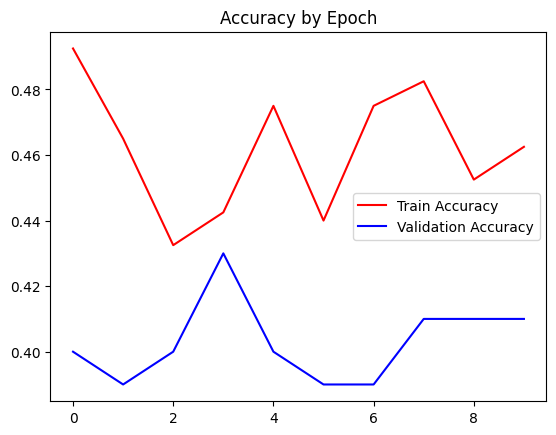

In [30]:
plt.plot(history.history['accuracy'],c="r")
plt.plot(history.history['val_accuracy'],c="b")
plt.legend(['Train Accuracy','Validation Accuracy'])
plt.title("Accuracy by Epoch")
plt.show()

#*What Does Our Rule Look Like?*

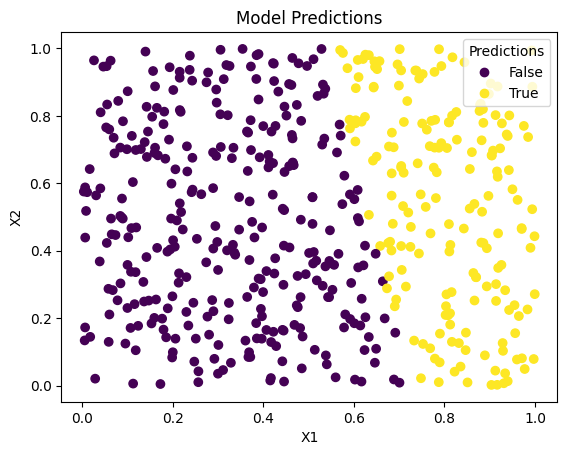

In [31]:
predictions = model(X)

scatter = plt.scatter(X[:,0],X[:,1],c=(predictions.numpy()>0.5))
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend(handles=scatter.legend_elements()[0],title="Predictions",labels=['False','True'])
plt.title("Model Predictions")

plt.show()

#*We can summarize our network like this*

Parameter count by layer like this...

In [32]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (20, 2)                │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (20, 1)                │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11 (48.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

Visually like this...

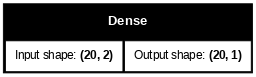

In [13]:
keras.utils.plot_model(model,show_shapes=True, dpi=60)